In [9]:
import pandas as pd
import numpy as np
import torch
import requests
from PIL import Image
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [10]:
import torch
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])

model = model.to(device)
model.eval()

torch.backends.cudnn.benchmark = True

In [11]:
import torchvision.transforms as transforms
preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [12]:
session = requests.Session()

def load_image(url):

    try:
        r = session.get(url, timeout=7)

        if r.status_code != 200:
            return None

        img = Image.open(BytesIO(r.content)).convert("RGB")
        img = preprocess(img)

        return img

    except:
        return None

In [13]:
def load_images_parallel(urls, ids, workers=32):

    images = []
    valid_ids = []

    with ThreadPoolExecutor(max_workers=workers) as executor:
        results = list(executor.map(load_image, urls))

    for img, pid in zip(results, ids):
        if img is not None:
            images.append(img)
            valid_ids.append(pid)

    return images, valid_ids

In [14]:
from tqdm import tqdm

def generate_embeddings(urls, ids, chunk_id, batch_size=256):

    embeddings = []
    valid_ids = []

    total_batches = (len(urls) + batch_size - 1) // batch_size

    for start in tqdm(
        range(0, len(urls), batch_size),
        total=total_batches,
        desc=f"Chunk {chunk_id}",
        unit="batch"
    ):

        batch_urls = urls[start:start+batch_size]
        batch_ids = ids[start:start+batch_size]

        images, good_ids = load_images_parallel(batch_urls, batch_ids)

        if len(images) == 0:
            continue

        batch = torch.stack(images).to(device)

        with torch.no_grad():
            emb = model(batch)

        emb = emb.view(emb.size(0), -1).cpu().numpy()

        embeddings.append(emb)
        valid_ids.extend(good_ids)

    if len(embeddings) == 0:
        return None, None

    embeddings = np.concatenate(embeddings, axis=0)

    return embeddings, np.array(valid_ids)

In [37]:
import pandas as pd
import numpy as np
import os

reader = pd.read_csv("usa_europe_geotagged.csv", chunksize=10000)

EMB_DIR = "embeddings"
os.makedirs(EMB_DIR, exist_ok=True)

START_CHUNK = 693

for i, chunk in enumerate(reader):

    if i < START_CHUNK:
        continue

    urls = chunk["downloadurl"].tolist()
    ids = chunk["photoid"].tolist()

    embeddings, valid_ids = generate_embeddings(urls, ids, i)

    if embeddings is None:
        print(f"Chunk {i}: no valid images")
        continue

    np.save(f"{EMB_DIR}/embeddings_chunk_{i}.npy", embeddings)
    np.save(f"{EMB_DIR}/ids_chunk_{i}.npy", valid_ids)

Chunk 767: 100%|██████████| 10/10 [00:45<00:00,  4.53s/batch]


In [15]:
import pandas as pd
import numpy as np
import os

reader = pd.read_csv("usa_europe_geotagged.csv", chunksize=10000)

EMB_DIR = "embeddings"
os.makedirs(EMB_DIR, exist_ok=True)

START_CHUNK = 390
END_CHUNK = 392

for i, chunk in enumerate(reader):

    if i < START_CHUNK:
        continue
    if i > END_CHUNK:
        break

    urls = chunk["downloadurl"].tolist()
    ids = chunk["photoid"].tolist()

    embeddings, valid_ids = generate_embeddings(urls, ids, i)

    if embeddings is None or len(valid_ids) == 0:
        print(f"Chunk {i}: no valid images")
        continue

    np.save(f"{EMB_DIR}/embeddings_chunk_{i}.npy", embeddings)
    np.save(f"{EMB_DIR}/ids_chunk_{i}.npy", valid_ids)

    print(f"Chunk {i} saved ({len(valid_ids)} embeddings)")

Chunk 390: 100%|██████████| 40/40 [01:30<00:00,  2.27s/batch]


Chunk 390 saved (8516 embeddings)


Chunk 391: 100%|██████████| 40/40 [02:49<00:00,  4.24s/batch]


Chunk 391 saved (7326 embeddings)


Chunk 392: 100%|██████████| 40/40 [01:28<00:00,  2.21s/batch]


Chunk 392 saved (8934 embeddings)


COMBINING THE CHUNKS TO ONE FAISS FILE --------

In [1]:
import numpy as np
import faiss
import os
from tqdm import tqdm
import pandas as pd

In [2]:
embedding_dir = "embeddings"   
ids_dir = "ids"                

faiss_index_file = "visual_embeddings.index"
id_map_file = "faiss_id_map.npy"

In [3]:
embedding_files = sorted(
    [f for f in os.listdir(embedding_dir) if f.endswith(".npy")]
)

id_files = sorted(
    [f for f in os.listdir(ids_dir) if f.endswith(".npy")]
)

print("Embedding chunks:", len(embedding_files))
print("ID chunks:", len(id_files))

Embedding chunks: 768
ID chunks: 768


In [4]:
dimension = 2048
nlist = 4096   # number of clusters
m = 32         # PQ segments

quantizer = faiss.IndexFlatL2(dimension)

index = faiss.IndexIVFPQ(
    quantizer,
    dimension,
    nlist,
    m,
    8
)

print("Index created")

Index created


In [5]:
train_vectors = []

for file in embedding_files[:5]:  # first few chunks
    emb = np.load(os.path.join(embedding_dir, file))
    train_vectors.append(emb[:20000])

train_vectors = np.vstack(train_vectors).astype("float32")

print(train_vectors.shape)

(44448, 2048)


In [6]:
index.train(train_vectors)

print("FAISS index trained")

FAISS index trained


In [7]:
all_ids = []

for emb_file, id_file in tqdm(zip(embedding_files, id_files), total=len(embedding_files)):

    emb_path = os.path.join(embedding_dir, emb_file)
    id_path = os.path.join(ids_dir, id_file)

    embeddings = np.load(emb_path).astype("float32")
    ids = np.load(id_path)

    index.add(embeddings)

    all_ids.extend(ids)

print("Total vectors indexed:", index.ntotal)

100%|████████████████████████████████████████████████████████████████████████████████| 768/768 [22:29<00:00,  1.76s/it]

Total vectors indexed: 6912381


In [10]:
faiss.write_index(index, faiss_index_file)

np.save(id_map_file, np.array(all_ids))

print("Index saved successfully")

NameError: name 'faiss' is not defined

In [9]:
id_map = np.load(id_map_file)

query = embeddings[0].reshape(1,-1)

D, I = index.search(query, 5)

print("Neighbor IDs:", id_map[I[0]])

NameError: name 'id_map_file' is not defined

TESTING IT VISUALLY ----------------


D:\ANACONDA\envs\gpu_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\ANACONDA\envs\gpu_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Top 5 neighbor IDs : [  113815005 13856129953  4392105564  2523839211  2215958548]
Distances          : [179.45154 182.39886 183.9968  186.32092 186.6138 ]


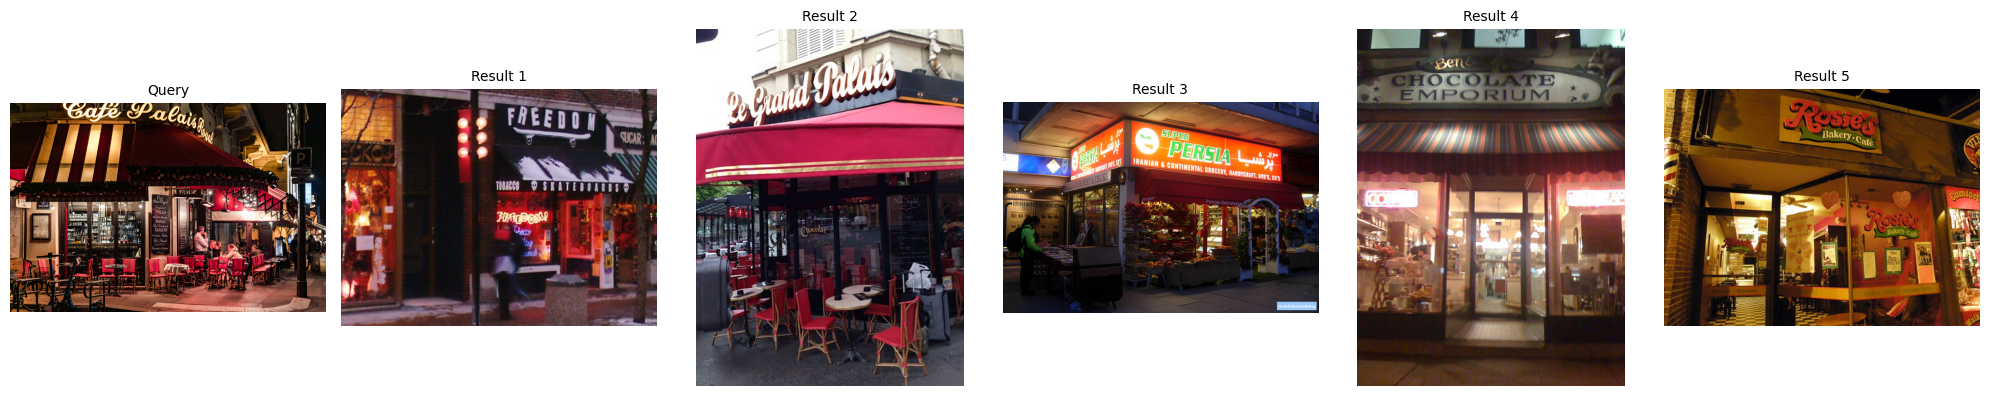

In [1]:
import faiss
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import csv

# ── load model ──────────────────────────────────────────────
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

# ── load faiss index & id map ────────────────────────────────
index  = faiss.read_index("visual_embeddings.index")
id_map = np.load("faiss_id_map.npy")

# ── load id → url mapping ────────────────────────────────────
id_to_url = {}
with open("usa_europe_geotagged.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        id_to_url[int(row["photoid"])] = row["downloadurl"]

# ── transform ────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── get query embedding ──────────────────────────────────────
query_img = Image.open("test_image.jpg").convert("RGB")
x         = transform(query_img).unsqueeze(0)

with torch.no_grad():
    emb = model(x).squeeze().numpy().astype("float32").reshape(1, -1)

# ── search top 5 ─────────────────────────────────────────────
D, I        = index.search(emb, 5)
neighbor_ids = id_map[I[0]]

print("Top 5 neighbor IDs :", neighbor_ids)
print("Distances          :", D[0])

# ── display ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 6, figsize=(20, 4))

axes[0].imshow(query_img)
axes[0].set_title("Query", fontsize=10)
axes[0].axis("off")

for idx, pid in enumerate(neighbor_ids):
    url = id_to_url.get(int(pid), None)
    try:
        response = requests.get(url, timeout=5)
        img      = Image.open(BytesIO(response.content)).convert("RGB")
        axes[idx+1].imshow(img)
        axes[idx+1].set_title(f"Result {idx+1}", fontsize=10)
    except:
        axes[idx+1].set_title(f"Result {idx+1}\n(unavailable)", fontsize=10)
    axes[idx+1].axis("off")

plt.tight_layout()
plt.show()